# The Changing Danish Welfare State

## How Denmark’s public spending priorities changed as the economy grew

When people talk about the Danish welfare state, it is often treated as one big system. But public spending is actually split across many different areas, such as health, education, defence, social protection, public administration, and more.

In this project, I use data from Danmarks Statistik to look at Danish public spending from 1995 to 2025. The goal is not just to see whether the state spends more money over time, but to understand whether the priorities inside the public budget have changed as the economy has grown.

The story starts with the broad economic picture, then looks at how public spending is divided across COFOG categories, and finally lets the reader explore what is hidden inside each main spending area.

## The question

Has Danish public spending simply grown with the economy, or have the priorities inside the public budget changed?

To investigate this, I combine two datasets from Danmarks Statistik:

- **NAN1**, which provides annual GDP data.
- **COFOG/OFF29**, which divides public spending into categories.

Together, these datasets make it possible to compare public spending with economic growth and then look more closely at how the structure of spending changed over time.

The analysis follows a simple path: first, I compare public spending with GDP; then I look at where the money goes across the main COFOG categories; and finally, the interactive chart lets the reader open up individual categories and explore the subcategories inside them.

## Public spending compared to economic growth

This chart gives the economic background for the project. Instead of only asking whether public spending increased, we can ask whether it grew faster or slower than the Danish economy.

However, this only tells us about the overall size of public spending. It does not tell us what the money was actually spent on. To understand whether priorities changed, we need to look inside the public budget.

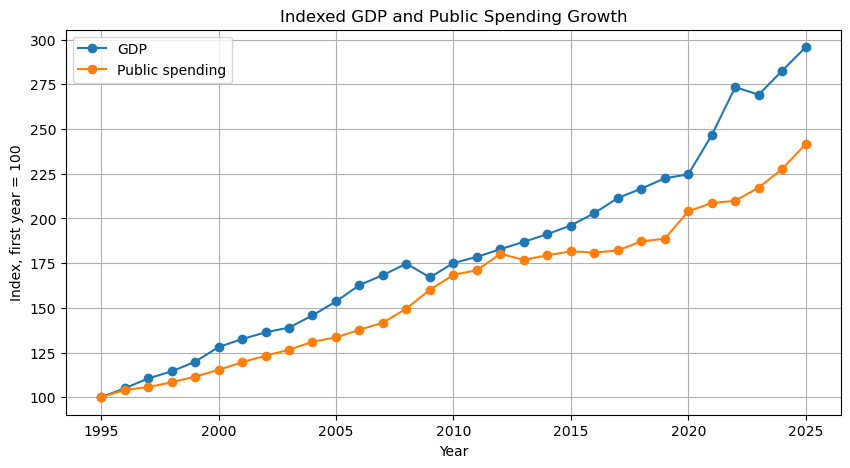

In [22]:
from IPython.display import Image, display

display(Image(filename="public spending indexed gdp.png"))

Both GDP and public spending increased a lot from 1995 to 2025, but GDP grew faster overall. Because both lines start at 100, the chart shows relative growth rather than raw money values.

So the first takeaway is that Denmark became wealthier, and public spending also grew, but not at exactly the same pace. The next question is what that public money was actually spent on.

## Where does public money go?

Public spending is not one single block. COFOG breaks it into ten main categories, such as social protection, health, education, defence, public administration, and economic affairs.

This lets us move from the overall size of public spending to the structure inside the public budget.

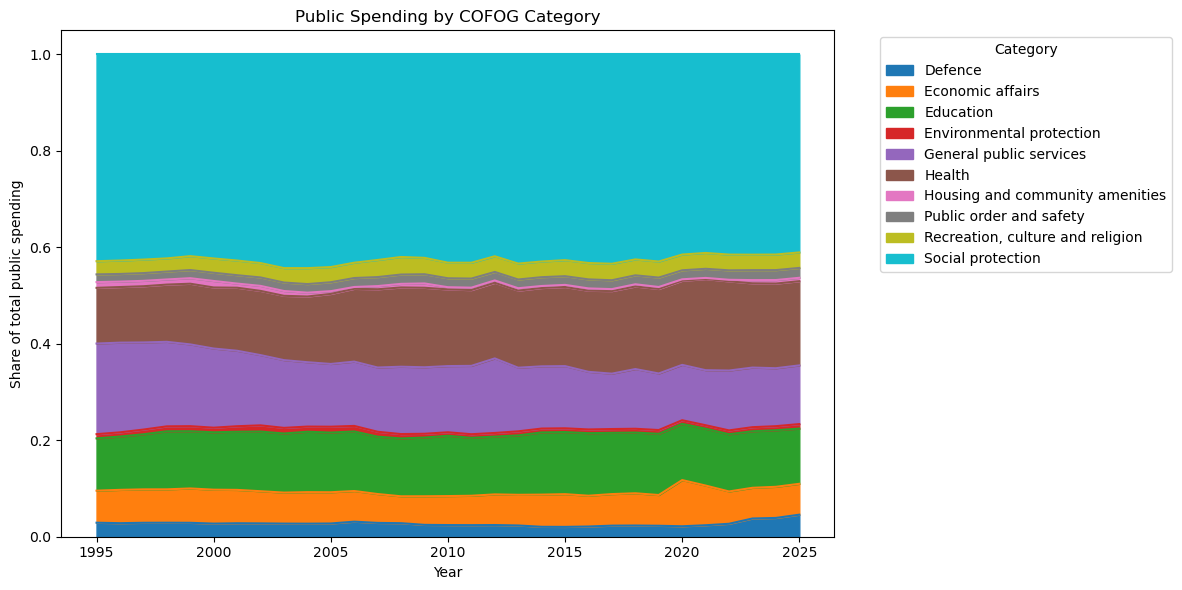

In [23]:
display(Image(filename="spending by category.png", width=900))

The chart shows that Danish public spending is dominated by a few large welfare areas. Social protection takes up the biggest share throughout the period, while health, education, and general public services also make up large parts of the budget.

At first glance, the overall structure looks fairly stable. But a stacked chart can make it hard to see which categories actually gained or lost importance. So the next step is to compare the beginning and end of the period more directly.

## Which spending areas changed the most?

To make the changes clearer, this chart compares each category’s share of total public spending in 1995 and 2025.

Positive values mean that a category became a larger part of the public budget. Negative values mean that it became a smaller part.

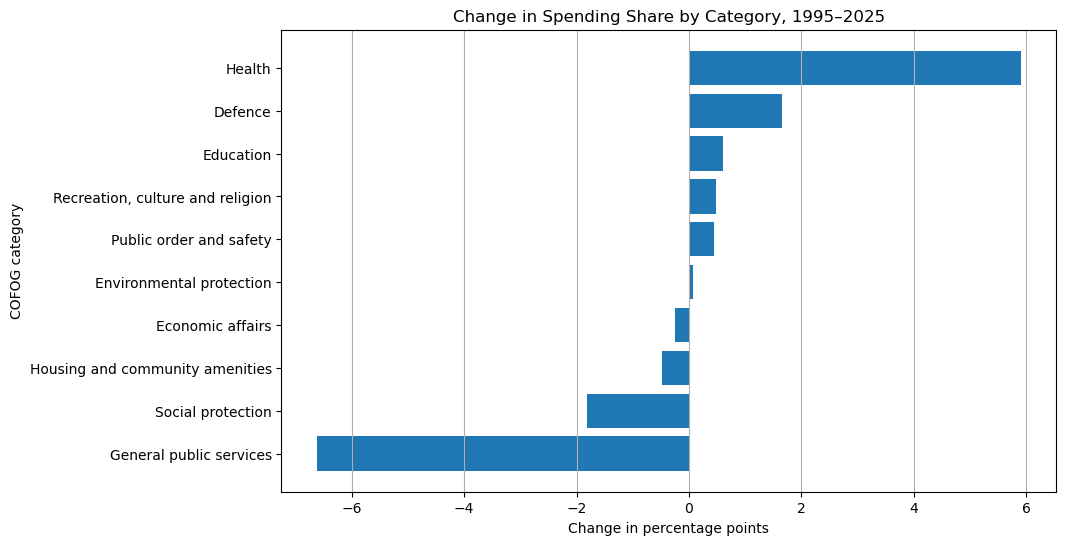

In [24]:
display(Image(filename="spending change.png", width=900))

The biggest increase is clearly health, which became a larger share of total public spending between 1995 and 2025. Defence also grew as a share of the budget, while general public services decreased the most.

Since health stands out the most in this chart, it makes sense to zoom in on it and look at how it developed compared to the economy as a whole.

## Health as a welfare-state case study

Health is the category that increased the most as a share of public spending, so I use it here as a closer example of how one part of the welfare state changed over time.

By comparing health spending to GDP, we can see whether health also became larger relative to Denmark’s economy, not just relative to the public budget.

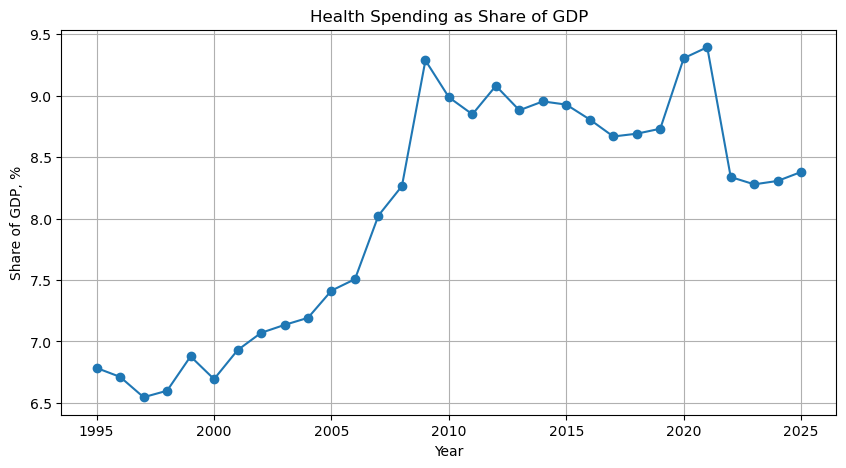

In [25]:
display(Image(filename="sundhedsvæsen spending.png", width=900))

Health spending rises a lot from the mid-2000s, with clear peaks around 2009 and again around 2020–2021. These jumps should not be read too simply, because healthcare spending can be affected by changes in how the system is organized, political priorities, and major events like COVID-19.

But health is still only one example. The other COFOG categories also contain many smaller subcategories, and showing all of them in one static chart would quickly become messy. So the final chart lets the reader explore one category at a time.

Health was useful to zoom in on, but it is only one part of the public budget. To understand the other categories, the reader needs a way to open them up without seeing everything at once.

In [26]:
import pandas as pd
import json
import re
from pathlib import Path

cofog_wide = pd.read_excel("OFF29.xlsx", header=2)
# Rename first column to year
cofog_wide = cofog_wide.rename(columns={cofog_wide.columns[0]: "year"})
cofog_wide["year"] = cofog_wide["year"].astype(int)

cofog = cofog_wide.melt(
    id_vars="year",
    var_name="category",
    value_name="spending_million_dkk"
)
cofog["spending_million_dkk"] = pd.to_numeric(
    cofog["spending_million_dkk"],
    errors="coerce"
)

main_categories = [
    "1. Generelle offentlige tjenester",
    "2. Forsvar",
    "3. Offentlig orden og sikkerhed",
    "4. Økonomiske anliggender",
    "5. Miljøbeskyttelse",
    "6. Boliger og offentlige faciliteter",
    "7. Sundhedsvæsen",
    "8. Fritid, kultur og religion",
    "9. Undervisning",
    "10. Social beskyttelse"
]

def get_category_code(category):
    """
    Extracts the COFOG code from a category string.
    Example:
    '7. Sundhedsvæsen' -> '7'
    '7.3. Hospitalstjenester' -> '7.3'
    """
    match = re.match(r"^(\d+(?:\.\d+)?)\.", str(category))
    return match.group(1) if match else None

def get_parent_code(category):
    """
    Gets the main parent category.
    Example:
    '7.3. Hospitalstjenester' -> '7'
    """
    code = get_category_code(category)
    return code.split(".")[0] if code else None

cofog["code"] = cofog["category"].apply(get_category_code)
cofog["parent_code"] = cofog["category"].apply(get_parent_code)
cofog["is_main_category"] = cofog["category"].isin(main_categories)

# Main categories only
cofog_main = cofog[cofog["is_main_category"]].copy()

# Subcategories only
cofog_sub = cofog[~cofog["is_main_category"]].copy()

# Latest year for overview bar chart
latest_year = cofog["year"].max()

overview_data = cofog_main[cofog_main["year"] == latest_year].copy()
overview_data = overview_data.sort_values("spending_million_dkk", ascending=True)

# Overview data: main category spending in latest year
overview = {
    "year": int(latest_year),
    "categories": overview_data["category"].tolist(),
    "values": (overview_data["spending_million_dkk"] / 1000).round(2).tolist(), # billion DKK
    "parent_codes": overview_data["parent_code"].tolist()
}

# Subcategory data for each main category
sub_data = {}

for main_cat in main_categories:
    parent_code = get_parent_code(main_cat)
    
    temp = cofog_sub[cofog_sub["parent_code"] == parent_code].copy()
    
    # Create one line per subcategory
    traces = []
    for subcat in temp["category"].unique():
        subcat_data = temp[temp["category"] == subcat].sort_values("year")
        
        traces.append({
            "name": subcat,
            "x": subcat_data["year"].astype(int).tolist(),
            "y": (subcat_data["spending_million_dkk"] / 1000).round(2).tolist() # billion DKK
        })
    
    sub_data[parent_code] = {
        "main_category": main_cat,
        "traces": traces
    }

In [27]:
import plotly.graph_objects as go

fig = go.Figure()

buttons = []
trace_indices_by_category = {}
trace_index = 0

# Choose default category
default_category = "7. Sundhedsvæsen"

for main_cat in main_categories:
    parent_code = get_parent_code(main_cat)
    data = cofog_sub[cofog_sub["parent_code"] == parent_code].copy()
    data = data.sort_values(["category", "year"])

    indices = []

    for subcat in data["category"].unique():
        subcat_data = data[data["category"] == subcat].sort_values("year")

        fig.add_trace(go.Scatter(
            x=subcat_data["year"],
            y=subcat_data["spending_million_dkk"] / 1000,
            mode="lines+markers",
            name=subcat,
            visible=(main_cat == default_category),
            hovertemplate=(
                "<b>%{fullData.name}</b><br>"
                "Year: %{x}<br>"
                "Spending: %{y:.2f} billion DKK"
                "<extra></extra>"
            )
        ))

        indices.append(trace_index)
        trace_index += 1

    trace_indices_by_category[main_cat] = indices

total_traces = len(fig.data)

for main_cat in main_categories:
    visible = [False] * total_traces

    for idx in trace_indices_by_category[main_cat]:
        visible[idx] = True

    buttons.append(dict(
        label=main_cat,
        method="update",
        args=[
            {"visible": visible},
            {
                "title": f"Inside {main_cat}",
                "yaxis": {"title": "Spending, billion DKK"},
                "xaxis": {"title": "Year"}
            }
        ]
    ))

fig.update_layout(
    title=f"Inside {default_category}",
    xaxis_title="Year",
    yaxis_title="Spending, billion DKK",
    height=650,
    hovermode="x unified",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0,
            y=1.15,
            showactive=True
        )
    ],
    legend=dict(
        orientation="h",
        y=-0.25
    )
)

fig.show()

The interactive chart shows why the main COFOG categories should not be seen as simple blocks. Each one contains smaller subcategories, and those subcategories can move in different directions over time.

For example, general public services looks like one category at first, but inside it, public debt transactions decrease a lot, while areas like basic research and administration grow. So even if a main category looks stable from the outside, the inside can still change quite a bit.

That is why this chart is mainly for exploration. It lets the reader move from the big story into the category they personally want to inspect more closely.

## What does this tell us?

Overall, Danish public spending did not just grow as one single block. GDP and public spending both increased from 1995 to 2025, but not at exactly the same pace. That gives the project its economic background.

Looking at the COFOG categories makes the story more interesting. Social protection stays as the largest category throughout the period, while health, education, and general public services also take up large parts of the public budget.

The clearest shift is that health became a larger share of public spending, while general public services became a smaller share. This suggests that the structure of public spending changed over time, even though the Danish welfare state still has the same recognizable core areas.

The interactive explorer adds the final layer: even the main categories are made up of smaller parts that can develop differently. So to understand public spending properly, we need both the big economic overview and a closer look inside the public budget.

## Technical details

This website presents the main story and visualizations. The full data cleaning, methodology, code, and additional explanations are available in the explainer notebook.

[View the explainer notebook](s224275.ipynb)